In [ ]:
from google.colab import files
files.upload()

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [ ]:
!kaggle datasets download -d puneet6060/intel-image-classification


In [4]:
!unzip -q intel-image-classification.zip -d data


In [49]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets,models,transforms
from torch.utils.data import DataLoader
import numpy as np
from sklearn.metrics import confusion_matrix,classification_report
import matplotlib.pyplot as plt


In [6]:
train_transform=transforms.Compose([
    transforms.RandomResizedCrop((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [7]:
test_transform=transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [8]:
train_data=datasets.ImageFolder('data/seg_train/seg_train',transform=train_transform)
test_data=datasets.ImageFolder('data/seg_test/seg_test',transform=test_transform)



In [9]:
train_loader=DataLoader(train_data,batch_size=32,shuffle=True)
test_loader=DataLoader(test_data,batch_size=32,shuffle=False)

In [10]:
model=models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 195MB/s]


In [11]:
model.fc=nn.Linear(model.fc.in_features,6)

In [12]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
model=model.to(device)

EXPERMINT 1

In [13]:
for param in model.parameters():
  param.requires_grad=False

  for param in model.fc.parameters():
    param.requires_grad=True

In [14]:
criterion=nn.CrossEntropyLoss()
optimizer=optim.Adam(model.fc.parameters(),lr=0.001)

In [15]:
 epochs=10
for epoch in range(epochs):
  model.train()
  running_loss=0.0
  correct=0
  total=0
  for images,labels in train_loader:
    images=images.to(device)
    labels=labels.to(device)
    optimizer.zero_grad()
    outputs=model(images)
    loss=criterion(outputs,labels)
    _,predicted=torch.max(outputs,1)
    loss.backward()
    optimizer.step()

    running_loss+=loss.item()
    total+=labels.size(0)
    correct+=(predicted==labels).sum().item()
  avg_loss=running_loss/len(train_loader)
  print("accuracy",100*correct/total)
  print("epoch",epoch+1,"loss",avg_loss)

accuracy 78.27419124982187
epoch 1 loss 0.6233052731850153
accuracy 83.96750748182984
epoch 2 loss 0.44076089224945714
accuracy 84.30953398888414
epoch 3 loss 0.41704188789620755
accuracy 84.90095482399886
epoch 4 loss 0.40719509207917237
accuracy 85.47099900242269
epoch 5 loss 0.3899158605274687
accuracy 84.58743052586576
epoch 6 loss 0.40700825549882746
accuracy 85.29286019666525
epoch 7 loss 0.3964423739726831
accuracy 85.32848795781673
epoch 8 loss 0.3953969392051458
accuracy 85.15747470428958
epoch 9 loss 0.3974850393305607
accuracy 85.35699016673792
epoch 10 loss 0.38935399517111463


In [16]:
model.eval()
correct=0
total=0
with torch.no_grad():
  for images,labels in test_loader:
    images=images.to(device)
    labels=labels.to(device)
    output=model(images)
    _,predicted=torch.max(output,1)
    total+=labels.size(0)
    correct+=(predicted==labels).sum().item()
print("accuracy",100*correct/total)


accuracy 89.46666666666667


EXPERIMENT 2

In [25]:
param_update=list(model.layer4.parameters())+list(model.fc.parameters())

In [ ]:
criterion=nn.CrossEntropyLoss()
optimizer=optim.Adam(param_update,lr=0.001)

In [21]:
epoch=10
for ep in range(epoch):
  model.train()
  running_time=0
  correct=0
  total=0
  for images,labels in train_loader:
    images=images.to(device)
    labels=labels.to(device)
    optimizer.zero_grad()
    output=model(images)
    loss=criterion(output,labels)
    _,predicted=torch.max(output,1)
    loss.backward()
    optimizer.step()

    total+=labels.size(0)
    correct+=(predicted==labels).sum().item()
    running_time+=loss.item()
  avg_loss=running_time/len(train_loader)
  print("accuracy",100*correct/total)
  print("epoch",ep+1,"loss",avg_loss)

accuracy 85.32136240558643
epoch 1 loss 0.39546621964230355
accuracy 85.25723243551376
epoch 2 loss 0.39773832193675507
accuracy 85.52800342026507
epoch 3 loss 0.39483737663826257
accuracy 85.66338891264073
epoch 4 loss 0.394828355427755
accuracy 85.68476556933162
epoch 5 loss 0.3884425587052636
accuracy 85.54938007695597
epoch 6 loss 0.3900131199992599
accuracy 85.60638449479835
epoch 7 loss 0.3895280500004123
accuracy 85.47812455465298
epoch 8 loss 0.39330210994954534
accuracy 85.49950121134388
epoch 9 loss 0.38598974324033036
accuracy 85.69901667379222
epoch 10 loss 0.38039208011773834


In [23]:
model.eval()
correct=0
total=0

with torch.no_grad():
  for images,labels in test_loader:
    images=images.to(device)
    labels=labels.to(device)
    output=model(images)
    _,predicted=torch.max(output,1)
    total+=labels.size(0)
    correct+=(predicted==labels).sum().item()
print("accuracy",(100*correct/total))

accuracy 89.5


EXPERIMENT 3

In [26]:
criterion=nn.CrossEntropyLoss()
optimizer=optim.Adam(param_update,lr=0.0001)


In [30]:
epoch=10
for ep in range(epoch):
  model.train()
  running_time=0
  correct=0
  total=0
  for images,labels in train_loader:
    images=images.to(device)
    labels=labels.to(device)
    optimizer.zero_grad()
    output=model(images)
    loss=criterion(output,labels)
    _,predicted=torch.max(output,1)
    loss.backward()
    optimizer.step()

    total+=labels.size(0)
    correct+=(predicted==labels).sum().item()
    running_time+=loss.item()
  avg_loss=running_time/len(train_loader)
  print("accuracy",100*correct/total)
  print("epoch",ep+1,"loss",avg_loss)

accuracy 85.83440216616788
epoch 1 loss 0.39900177561069133
accuracy 87.98631893971783
epoch 2 loss 0.3278560001309749
accuracy 89.30454610232293
epoch 3 loss 0.28786518419657864
accuracy 90.24511899672224
epoch 4 loss 0.2660121152300498
accuracy 90.82941427960667
epoch 5 loss 0.24449598622892332
accuracy 91.17856633889126
epoch 6 loss 0.23223905408742215
accuracy 91.81274048738777
epoch 7 loss 0.22234251886470444
accuracy 92.26165027789654
epoch 8 loss 0.21134571318253706
accuracy 92.19039475559356
epoch 9 loss 0.20774204154119133
accuracy 92.3542824568904
epoch 10 loss 0.20107019020155378


In [33]:
model.eval()
correct=0
total=0

with torch.no_grad():
  for images,labels in test_loader:
    images=images.to(device)
    labels=labels.to(device)
    output=model(images)
    _,predicted=torch.max(output,1)
    total+=labels.size(0)
    correct+=(predicted==labels).sum().item()
print("accuracy",(100*correct/total))

accuracy 92.93333333333334


EXPERIMENT 4

In [ ]:
model.fc=nn.Sequencial(
    nn.Dropout(p=0.5),nn.Linear(model.fc.in_features,6)
)

In [ ]:
param_update=list(model.layer4.parameters())+list(model.fc.parameters())

In [34]:
criterion=nn.CrossEntropyLoss()
optimizer=optim.Adam(param_update,lr=0.0001)

In [36]:
epoch=10
for ep in range(epoch):
  model.train()
  running_time=0
  correct=0
  total=0
  for images,labels in train_loader:
    images=images.to(device)
    labels=labels.to(device)
    optimizer.zero_grad()
    output=model(images)
    loss=criterion(output,labels)
    _,predicted=torch.max(output,1)
    loss.backward()
    optimizer.step()

    total+=labels.size(0)
    correct+=(predicted==labels).sum().item()
    running_time+=loss.item()
  avg_loss=running_time/len(train_loader)
  print("accuracy",100*correct/total)
  print("epoch",ep+1,"loss",avg_loss)

accuracy 92.7248111728659
epoch 1 loss 0.19422122244224596
accuracy 92.94570329200513
epoch 2 loss 0.19079330015359
accuracy 92.77469003847798
epoch 3 loss 0.18955826131809408
accuracy 93.52287302265925
epoch 4 loss 0.17598077059980133
accuracy 93.54424967935014
epoch 5 loss 0.1682631899464816
accuracy 93.75801624625909
epoch 6 loss 0.16389623508366474
accuracy 94.00028502208922
epoch 7 loss 0.1570001628338985
accuracy 93.91477839532564
epoch 8 loss 0.15584548403655343
accuracy 94.3993159469859
epoch 9 loss 0.1501863899965323
accuracy 94.30668376799201
epoch 10 loss 0.15113803011986823


In [48]:
model.eval()
correct=0
total=0

with torch.no_grad():
  for images,labels in test_loader:
    images=images.to(device)
    labels=labels.to(device)
    output=model(images)
    _,predicted=torch.max(output,1)
    total+=labels.size(0)
    correct+=(predicted==labels).sum().item()
print("accuracy",(100*correct/total))

accuracy 94.1


EXPERIMENT 5


In [39]:
criterion=nn.CrossEntropyLoss()
optimizer=optim.Adam(param_update,lr=0.0001,weight_decay=0.0001)

In [40]:
epoch=10
for ep in range(epoch):
  model.train()
  running_time=0
  correct=0
  total=0
  for images,labels in train_loader:
    images=images.to(device)
    labels=labels.to(device)
    optimizer.zero_grad()
    output=model(images)
    loss=criterion(output,labels)
    _,predicted=torch.max(output,1)
    loss.backward()
    optimizer.step()

    total+=labels.size(0)
    correct+=(predicted==labels).sum().item()
    running_time+=loss.item()
  avg_loss=running_time/len(train_loader)
  print("accuracy",100*correct/total)
  print("epoch",ep+1,"loss",avg_loss)

accuracy 94.29955821576172
epoch 1 loss 0.1513454373989568
accuracy 94.93373236425823
epoch 2 loss 0.13767023688152535
accuracy 94.32806042468292
epoch 3 loss 0.14934224166306995
accuracy 94.79834687188257
epoch 4 loss 0.13752648316468016
accuracy 95.07624340886419
epoch 5 loss 0.13460358753503388
accuracy 95.11187117001568
epoch 6 loss 0.13283474418358
accuracy 95.12612227447627
epoch 7 loss 0.13277379502934789
accuracy 95.0691178566339
epoch 8 loss 0.13244809862650542
accuracy 95.0406156477127
epoch 9 loss 0.13090067171939312
accuracy 94.93373236425823
epoch 10 loss 0.13509233253488237


In [41]:
model.eval()
correct=0
total=0

with torch.no_grad():
  for images,labels in test_loader:
    images=images.to(device)
    labels=labels.to(device)
    output=model(images)
    _,predicted=torch.max(output,1)
    total+=labels.size(0)
    correct+=(predicted==labels).sum().item()
print("accuracy",(100*correct/total))

accuracy 93.4


EXPERIMENT 6

In [42]:
criterion=nn.CrossEntropyLoss()
optimizer=optim.Adam(param_update,lr=0.0001,weight_decay=0.0001)
scheduler=optim.lr_scheduler.StepLR(optimizer,step_size=3,gamma=0.1)

In [43]:
epoch=10
for ep in range(epoch):
  model.train()
  running_time=0
  correct=0
  total=0
  for images,labels in train_loader:
    images=images.to(device)
    labels=labels.to(device)
    optimizer.zero_grad()
    output=model(images)
    loss=criterion(output,labels)
    _,predicted=torch.max(output,1)
    loss.backward()
    optimizer.step()

    total+=labels.size(0)
    correct+=(predicted==labels).sum().item()
    running_time+=loss.item()
  scheduler.step()
  avg_loss=running_time/len(train_loader)
  print("accuracy",100*correct/total)
  print("epoch",ep+1,"loss",avg_loss)

accuracy 95.41114436368818
epoch 1 loss 0.1262681958051335
accuracy 95.26863331908223
epoch 2 loss 0.1303054943441038
accuracy 95.73179421405159
epoch 3 loss 0.11891782490731745
accuracy 96.16645290009976
epoch 4 loss 0.10610415760835035
accuracy 96.46572609377226
epoch 5 loss 0.09514540314233114
accuracy 96.45147498931168
epoch 6 loss 0.09620277664108638
accuracy 96.26621063132393
epoch 7 loss 0.10342895725194645
accuracy 96.63673934729941
epoch 8 loss 0.09231332941129294
accuracy 96.45147498931168
epoch 9 loss 0.09556239768162642
accuracy 96.60111158614792
epoch 10 loss 0.09276729438810319


In [44]:
model.eval()
correct=0
total=0

with torch.no_grad():
  for images,labels in test_loader:
    images=images.to(device)
    labels=labels.to(device)
    output=model(images)
    _,predicted=torch.max(output,1)
    total+=labels.size(0)
    correct+=(predicted==labels).sum().item()
print("accuracy",(100*correct/total))

accuracy 93.6


In [45]:
criteripn=nn.CrossEntropyLoss()
optimizer=optim.Adam(param_update,lr=0.0001,weight_decay=0.0001)
scheduler=optim.lr_scheduler.StepLR(optimizer,step_size=3,gamma=0.1)

In [46]:
epoch=10
for ep in range(epoch):
  model.train()
  running_time=0
  correct=0
  total=0
  for images,labels in train_loader:
    images=images.to(device)
    labels=labels.to(device)
    optimizer.zero_grad()
    output=model(images)
    loss=criterion(output,labels)
    _,predicted=torch.max(output,1)
    loss.backward()
    optimizer.step()

    total+=labels.size(0)
    correct+=(predicted==labels).sum().item()
    running_time+=loss.item()
  scheduler.step()
  avg_loss=running_time/len(train_loader)
  print("accuracy",100*correct/total)
  print("epoch",ep+1,"loss",avg_loss)

accuracy 95.48952543822146
epoch 1 loss 0.11859738148201537
accuracy 95.49665099045176
epoch 2 loss 0.12189763498010966
accuracy 95.56790651275473
epoch 3 loss 0.1195450345073362
accuracy 96.19495510902095
epoch 4 loss 0.10573697072434704
accuracy 96.40159612369959
epoch 5 loss 0.10007212058257031
accuracy 96.86475701866895
epoch 6 loss 0.0870882680412628
accuracy 96.85763146643865
epoch 7 loss 0.0853112822229887
accuracy 96.25908507909362
epoch 8 loss 0.09441048853578797
accuracy 96.54410716830554
epoch 9 loss 0.09067870316611167
accuracy 96.86475701866895
epoch 10 loss 0.08950714608664988


In [47]:
model.eval()
correct=0
total=0

with torch.no_grad():
  for images,labels in test_loader:
    images=images.to(device)
    labels=labels.to(device)
    output=model(images)
    _,predicted=torch.max(output,1)
    total+=labels.size(0)
    correct+=(predicted==labels).sum().item()
print("accuracy",(100*correct/total))

accuracy 94.1


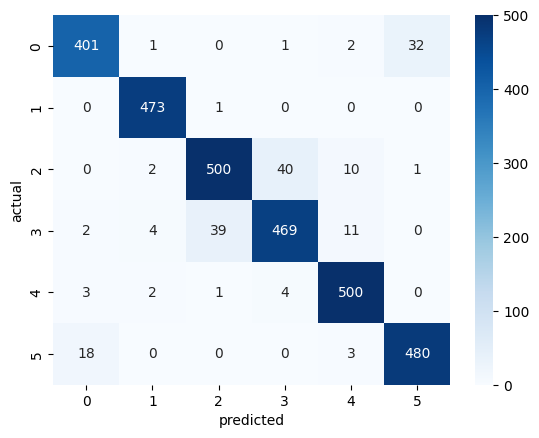

              precision    recall  f1-score   support

           0       0.95      0.92      0.93       437
           1       0.98      1.00      0.99       474
           2       0.92      0.90      0.91       553
           3       0.91      0.89      0.90       525
           4       0.95      0.98      0.97       510
           5       0.94      0.96      0.95       501

    accuracy                           0.94      3000
   macro avg       0.94      0.94      0.94      3000
weighted avg       0.94      0.94      0.94      3000



In [52]:
import seaborn as sns

model.eval()
all_labels=[]
all_pred=[]

with torch.no_grad():
  for images,labels in test_loader:
    images=images.to(device)
    labels=labels.to(device)
    output=model(images)
    _,predicted=torch.max(output,1)
    all_labels.extend(labels.cpu().numpy())
    all_pred.extend(predicted.cpu().numpy())

cm=confusion_matrix(all_labels,all_pred)
sns.heatmap(cm,annot=True,fmt="d",cmap='Blues')
plt.xlabel("predicted")
plt.ylabel("actual")
plt.show()

print(classification_report(all_labels,all_pred))